# Dynamic senescence modeling — minimal example (temporal vs spectral resolution)

**Paper:** Jonas Anderegg et al., *Temporal resolution trumps spectral resolution in UAV-based monitoring of canopy senescence dynamics*, bioRxiv 2023.12.13.571461v1 (2023-12-14) — https://doi.org/10.1101/2023.12.13.571461

**Author code:** https://github.com/ftschurr/dynamic_senescence_modeling @ commit `4798c129f50a3f1268edc52c40609b25bff5b2ed`

**What this notebook does (scope):** it runs the authors' **dynamic-modeling** pipeline (`R/01_fit_models.R` + `R/A_utils.R` + `R/B_helpers.R`) on a **small deterministic subset of the authors' own example data** (one RGB index file and one SPC index file, a few plots) and extracts the seven key senescence time points (**t20, t50, t80, onsen, endsen, durations, Integral**) using all four methods of the paper: linear interpolation, constrained Gompertz, flexible Gompertz, and monotone penalized splines.

**Execution status / scope limits:**
- The analysis is the **author's R code executed verbatim** (helpers) with one **adapted driver** derived from `01_fit_models.R` (see the mapping table below). AI-assisted adaptation of the driver; the authors did not provide this Colab implementation. The executed example and listed checks were validated, but untested behavior is not guaranteed.
- This is a **single small example, not a reproduction** of the paper's four-experiment comparison, index-model selection against visual scoring, or temporal-subsampling analysis (those need the full, non-public datasets).
- 日本語: このノートブックは著者提供のRコード（動的モデルリング節）を、著者公開のサンプルデータの小さい決定論的サブセットでColab上で実行します。4手法（線形補間、制約付きGompertz、柔軟Gompertz、単調Pスプライン）で7つのキータイムポイント（t20, t50, t80, onsen, endsen, 期間, 積分値）を抽出します。論文全体の再現ではありません。

**Note on the season windows:** the author pipeline filters each experiment to its senescence window (`filter_dates`). The example filenames carry no experiment id, so the id is inferred from each file's date range and the paper's Table 1 (RGB example → FPWW022 2018 window; SPC example → FPWW033 2022 window); window dates are the author's verified values.

**Runtime:** standard **CPU** runtime is sufficient (small curve fitting; no GPU code in the author pipeline). Recommended: Runtime → Change runtime type → CPU. Estimated wall time ~15–25 min (mostly R package installation); downloads ≈ 2 MB.


## Environment check

This notebook runs the authors' R code. Google Colab CPU images ship `/usr/bin/Rscript`; the Python kernel here is only the **launcher**. This cell verifies R and prints its version.

日本語: Pythonカーネルは起動装置のみで、解析自体は著者のRコードを `Rscript` で実行します。まずRの存在とバージョンを確認します。

In [ ]:
import subprocess, shutil, sys, textwrap

rscript = shutil.which("Rscript")
if rscript is None:
    raise RuntimeError("Rscript not found. Select a standard Colab runtime; if R is missing, install it via apt (see README).")
print("Rscript:", rscript)
r = subprocess.run([rscript, "-e", 'cat(R.version.string); cat("\n"); cat(.libPaths(), sep="\n")'],
                   check=True, capture_output=True, text=True, timeout=120)
print(r.stdout)
if r.stderr.strip():
    print(r.stderr)

Rscript: /usr/bin/Rscript


R version 4.6.1 (2026-06-24)
/usr/local/lib/R/site-library
/usr/lib/R/site-library
/usr/lib/R/library



## Install required R packages

Dependencies are the exact packages used by the pinned author scripts (`R/01_fit_models.R` imports: tidyverse core, data.table, nls.multstart, scam, progress, R.utils, broom; plotting/parallel extras are not needed for this subset run). Everything installs from CRAN inside this Colab VM. `scam` compiles C code, so this cell may take **5–15 minutes**; progress is streamed.

日本語: 著者スクリプトが必要とするRパッケージをCRANからインストールします。scamはCコンパイルを含むため5〜15分かかることがあります。

In [ ]:
import time

pkgs = ("data.table dplyr tidyr purrr ggplot2 tibble reshape2 "
        "nls.multstart scam progress R.utils broom").split()
t0 = time.time()
cmd = (
    'options(warn=1); '
    'new <- setdiff(c(' + ", ".join(f"'{p}'" for p in pkgs) + '), rownames(installed.packages())); '
    'if (length(new)) install.packages(new, repos="https://cloud.r-project.org", Ncpus=2); '
    'for (p in c(' + ", ".join(f"'{p}'" for p in pkgs) + ')) '
    '  cat(p, as.character(packageVersion(p)), "\n")'
)
subprocess.run([rscript, "-e", cmd], check=True, timeout=3600)
print(f"R packages ready in {time.time()-t0:.0f} s")

R packages ready in 155 s


## Download pinned author code and example data

All inputs come from the pinned commit `4798c12` of `ftschurr/dynamic_senescence_modeling` via raw.githubusercontent.com. Each file is verified against its **git blob SHA-1** from the GitHub tree of that exact commit (metadata obtained from the GitHub API). Only two of the 41 example CSVs are downloaded (~2 MB total); dataset bytes stay on this Colab VM.

日本語: コードとサンプルデータ2ファイル（RGB系GCC指数とSPC系NDVIred650指数）をピン留めされたコミットから取得し、git blob SHA-1で検証します。

In [ ]:
import hashlib, urllib.request, pathlib

COMMIT = "4798c129f50a3f1268edc52c40609b25bff5b2ed"
BASE = f"https://raw.githubusercontent.com/ftschurr/dynamic_senescence_modeling/{COMMIT}"

FILES = {  # path -> git blob sha1 at the pinned commit
    "R/01_fit_models.R": "69efb241fa5f4005c1011cdabe19b819694d22e0",
    "R/A_utils.R":       "cc8ee911a35ea4aed102817b4ae5e3f1b7de8b35",
    "R/B_helpers.R":     "66e4754aa693514086469f02640a63d75fb979e8",
    "data/RGB_example/RGB_example_GCC_RGB.csv": "6d4d6457623720e844d99c3c3addffdae046a942",
    "data/SPC_example/SPC_example_NDVIred650_multispec_empirical_line_LM.csv": "e4084ba4323d6ce1cb9367665102728ff62021ab",
}

def git_blob_sha(b: bytes) -> str:
    return hashlib.sha1(b"blob %d\x00" % len(b) + b).hexdigest()

dest = pathlib.Path("/content/dsm")
for rel, sha in FILES.items():
    out = dest / rel
    out.parent.mkdir(parents=True, exist_ok=True)
    with urllib.request.urlopen(f"{BASE}/{rel}", timeout=120) as resp:
        b = resp.read()
    assert resp.status == 200 and git_blob_sha(b) == sha, f"verification failed for {rel}"
    out.write_bytes(b)
    print(f"OK  {rel:70s} {len(b):>9,d} B  blob {git_blob_sha(b)[:12]}...")
print("All downloads verified against pinned git blob hashes.")

OK  R/01_fit_models.R                                                          5,251 B  blob 69efb241fa5f...


OK  R/A_utils.R                                                               21,395 B  blob cc8ee911a35e...


OK  R/B_helpers.R                                                              1,895 B  blob 66e4754aa693...


OK  data/RGB_example/RGB_example_GCC_RGB.csv                               1,530,063 B  blob 6d4d64576237...


OK  data/SPC_example/SPC_example_NDVIred650_multispec_empirical_line_LM.csv   495,153 B  blob e4084ba4323d...
All downloads verified against pinned git blob hashes.


## Driver script (adapted from `R/01_fit_models.R`)

The author functions `A_utils.R` / `B_helpers.R` are used **verbatim** (downloaded above). The driver below is a documented, minimal adaptation of the authors' `01_fit_models.R`:

| Original (`01_fit_models.R`) | Here | Why |
| --- | --- | --- |
| loop over all 41 CSV files with a `doParallel` cluster | 2 files, sequential | smallest faithful demonstration; cluster adds no scientific change |
| `filter_dates(dat, id)` with the id parsed from the filename | `filter_dates(dat, id)` with the id **inferred from the file's date range + paper Table 1** (RGB example → `FPWW022`, SPC example → `FPWW033`) | example filenames carry no `FPWW/ESWW` token, so the author's id parsing returns `NULL` and `filter_dates` would fail; window dates themselves are the author's verified values |
| all plots of an experiment | first **4** sorted `plot.UID` values per file | deterministic small subset |
| `plot_dynamics = TRUE` (writes PDFs, uses a global `id`, unseeded `sample()`) | `plot_dynamics = FALSE`; own labeled figure afterwards | keeps author numerics unchanged |
| output `.rds` to a Windows scratch dir | CSV + list output under `/content/dsm/out` | Colab paths |

Scientific operations — scaling to 0–10, series-length filter, the four fitting methods and all parameter extraction — are the author's unchanged code.

日本語: 著者の関数はそのまま使用し、ドライバのみ最小限の適応（2ファイル・4プロット・逐次実行・図の自作）を加えています。科学的部分（スケーリング、4手法の fit、パラメータ抽出）は著者コードのままです。

In [ ]:
import pathlib

DRIVER = r"""# driver.R — minimal adaptation of ftschurr/dynamic_senescence_modeling @ 4798c12, R/01_fit_models.R
# Author functions are used verbatim; this driver only subsets files/plots and changes I/O.
suppressPackageStartupMessages({
  library(data.table); library(dplyr); library(tidyr); library(purrr)
  library(ggplot2); library(tibble); library(reshape2); library(nls.multstart)
  library(scam); library(progress); library(R.utils); library(broom)
})
# dplyr removed nothing here, but guard the deprecated n_groups() used inside A_utils.R
if (is.null(get0("n_groups", envir = asNamespace("dplyr")))) {
  n_groups <- function(x) nrow(attr(x, "groups"))
}

source("/content/dsm/R/A_utils.R")   # author functions, verbatim
source("/content/dsm/R/B_helpers.R") # author functions, verbatim

out_dir <- "/content/dsm/out"; dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)
N_PLOTS <- 6  # deterministic subset: first 6 sorted plot UIDs per file

process_file <- function(path, id) {
  bn <- basename(path)
  cat("file:", bn, "| experiment id:", id, "\n")

  # --- identical to author pipeline ---
  dat <- data.table::fread(path) %>%
    dplyr::select(plot.UID, date, index_name, median_value) %>%
    mutate(index_name = paste0("SI_", index_name)) %>%
    mutate(date = as.Date(date, format = "%Y-%m-%d"))
  dat <- filter_dates(dat, id)   # author helper; id derived from file dates, see mapping table
  cat("date range:", format(min(dat$date)), "to", format(max(dat$date)),
      "|", n_distinct(dat$plot.UID), "plots\n")

  d_wide <- dat %>% pivot_wider(names_from = index_name, values_from = median_value) %>%
    rename("plot_UID" = plot.UID) %>%
    mutate(date = as.Date(date)) %>%
    group_by(plot_UID, date) %>% nest() %>%
    rename("SVI" = data, "meas_date" = date)

  exp_plots <- sort(unique(d_wide$plot_UID))[seq_len(min(N_PLOTS, n_distinct(d_wide$plot_UID)))]
  cat("selected plots:", paste(exp_plots, collapse = ", "), "\n")
  SVI <- d_wide %>%
    dplyr::filter(plot_UID %in% exp_plots) %>%
    dplyr::select(plot_UID, meas_date, SVI) %>%
    mutate(SVI = purrr::map(SVI, data.table::as.data.table)) %>%
    mutate(Treatment = "None")
  svi <- gsub("SI_", "", names(SVI$SVI[[1]]))

  SVI <- check_series(data = SVI, min_length = 5)   # author: drop plots with <5 measurements
  data <- scale_SVI(data = SVI, plotid = "plot_UID", treatid = "Treatment", plot = FALSE)

  parameters <- get_svi_dynamics(data = data, svi = svi, type = "scaled",
    method = c("linear", "cgom", "fgom", "pspl"), timevar = "dafm",
    pred_freq = 0.25, plot_dynamics = FALSE, output_dir = out_dir)  # author function

  pars <- parameters$parameters
  stem <- tools::file_path_sans_ext(bn)
  fwrite(as.data.table(pars), file.path(out_dir, paste0(stem, "_pars.csv")))

  # ---- fit-curve records for one example plot (first of the subset) ----
  target <- sort(unique(pars$Plot_ID))[1]
  fits <- parameters$fits
  tp   <- parameters$timepoints$timevar
  rows <- list()
  for (v in unique(fits$variable)) {
    fr <- fits[fits$variable == v & fits$Plot_ID == target, ]
    obs <- fr$data[[1]]
    rows[[length(rows) + 1]] <- data.frame(Plot_ID = target, variable = v, method = "observed",
      timevar = obs$timevar, prediction = obs$value, is_observed = TRUE)
    for (m in c("preds_lin", "preds_cgom", "preds_fgom", "preds_pspl")) {
      if (m %in% names(fr)) {
        rows[[length(rows) + 1]] <- data.frame(Plot_ID = target, variable = v,
          method = sub("preds_", "", m), timevar = tp,
          prediction = as.numeric(fr[[m]][[1]][[1]]), is_observed = FALSE)
      }
    }
  }
  fwrite(rbindlist(rows), file.path(out_dir, paste0(stem, "_curves_", target, ".csv")))
  cat("wrote", paste0(stem, "_pars.csv"), "and curves for plot", target, "\n")
  invisible(NULL)
}

# Experiment ids inferred from the files' date ranges and the paper's Table 1
# (RGB/SPC acquired for FIP main 2018/2021/2022); windows are the author's verified values.
process_file("/content/dsm/data/RGB_example/RGB_example_GCC_RGB.csv", "FPWW022")
process_file("/content/dsm/data/SPC_example/SPC_example_NDVIred650_multispec_empirical_line_LM.csv", "FPWW033")
cat("DONE\n")
"""
pathlib.Path("/content/dsm/driver.R").write_text(DRIVER)
print("driver.R written:", len(DRIVER), "chars")


driver.R written: 4154 chars


## Run the author pipeline

Runs `driver.R` with `Rscript`. Expect a few minutes: each plot/index gets a constrained Gompertz (300 starting-value rounds), a flexible Gompertz (500), and a monotone penalized-spline fit with a 2 s timeout (author's setting). Failures of individual fits surface here rather than being hidden.

日本語: `Rscript` で著者パイプラインを実行します。Gompertzの多開始点推定のため数分かかります。

In [ ]:
t0 = time.time()
proc = subprocess.Popen([rscript, "/content/dsm/driver.R"], stdout=subprocess.PIPE,
                        stderr=subprocess.STDOUT, text=True, bufsize=1)
for line in proc.stdout:
    print(line, end="")
proc.wait(timeout=3600)
if proc.returncode != 0:
    raise RuntimeError(f"driver.R failed with exit code {proc.returncode}")
print(f"driver.R finished in {time.time()-t0:.0f} s")

file: RGB_example_GCC_RGB.csv | experiment id: FPWW022 
date range: 2018-05-28 to 2018-07-04 | 378 plots
selected plots: RGB0001, RGB0002, RGB0003, RGB0004, RGB0005, RGB0006 


[1] "processing 1 indices ..."
[1] " -- Interpolating ..."
[1] " -- Fitting constrained Gompertz ..."


[1] " -- Fitting flexible Gompertz ..."


[1] " -- Fitting p-splines ..."


[1] " -- Extracting parameters ..."


wrote RGB_example_GCC_RGB_pars.csv and curves for plot RGB0001 
file: SPC_example_NDVIred650_multispec_empirical_line_LM.csv | experiment id: FPWW033 
date range: 2022-05-27 to 2022-07-18 | 180 plots
selected plots: SPC0001, SPC0002, SPC0003, SPC0004, SPC0005, SPC0006 


[1] "processing 1 indices ..."
[1] " -- Interpolating ..."
[1] " -- Fitting constrained Gompertz ..."


[1] " -- Fitting flexible Gompertz ..."


[1] " -- Fitting p-splines ..."


[1] " -- Extracting parameters ..."
wrote SPC_example_NDVIred650_multispec_empirical_line_LM_pars.csv and curves for plot SPC0001 
DONE
driver.R finished in 29 s


## Key senescence time points (extracted parameters)

Loads the two parameter CSVs written by the author's `get_svi_dynamics()`/`extract_pars()` and shows the extracted key time points. Time is **days after the first measurement** (`dafm`); values t20/t50/t80 are the dates when the scaled index (0–10 scale, senescence direction) crosses 2/5/8; `onsen`/`endsen` are the minima/maxima of the second derivative of the Gompertz fits; `dur1 = t50 − t80`, `dur2 = t20 − t80`; `Integral` is the area under the fitted curve. `onsen`/`endsen` are only defined for the Gompertz methods (author's design), so rows for `linear`/`pspl` show NA there.

日本語: 抽出されたキータイムポイント（dafm = 初回測定からの日数）を表示します。

In [ ]:
import pandas as pd

pars = pd.concat([
    pd.read_csv("/content/dsm/out/RGB_example_GCC_RGB_pars.csv").assign(source="RGB example (GCC index)"),
    pd.read_csv("/content/dsm/out/SPC_example_NDVIred650_multispec_empirical_line_LM_pars.csv").assign(source="SPC example (NDVIred650 index)"),
], ignore_index=True)

# author column naming: <method>_<parameter> (e.g. lin_t20, cgom_b, pspl_Integral)
method_stems = ("lin", "cgom", "fgom", "pspl")
param_cols = [c for c in pars.columns if c.split("_")[0] in method_stems]
long = pars.melt(id_vars=[c for c in pars.columns if c not in param_cols],
                 value_vars=param_cols, var_name="method_param", value_name="value").dropna(subset=["value"])
long["method"] = long["method_param"].str.split("_").str[0]
long["parameter"] = long["method_param"].str.split("_").str[1:].str.join("_")
key = long[long["parameter"].isin(["t20", "t50", "t80", "onsen", "endsen", "dur1", "dur2", "Integral"])]
table = key.pivot(index=["source", "Plot_ID", "variable", "method"],
                  columns="parameter", values="value")
table = table[["t20", "t50", "t80", "onsen", "endsen", "dur1", "dur2", "Integral"]].reset_index()
print(f"{len(table)} plot x method rows")
table.round(3)

48 plot x method rows


parameter,source,Plot_ID,variable,method,t20,t50,t80,onsen,endsen,dur1,dur2,Integral
0,RGB example (GCC index),RGB0001,SI_GCC_r,cgom,NaN,0.00,0.00,37.00,0.00,0.00,NaN,207.300
1,RGB example (GCC index),RGB0001,SI_GCC_r,fgom,NaN,0.00,0.00,7.25,6.75,0.00,NaN,213.297
2,RGB example (GCC index),RGB0001,SI_GCC_r,lin,3.50,2.50,0.00,NaN,NaN,2.50,3.50,216.553
3,RGB example (GCC index),RGB0001,SI_GCC_r,pspl,NaN,NaN,0.00,NaN,NaN,NaN,NaN,207.479
4,RGB example (GCC index),RGB0002,SI_GCC_r,cgom,NaN,0.00,0.00,37.00,0.00,0.00,NaN,154.309
5,RGB example (GCC index),RGB0002,SI_GCC_r,fgom,NaN,0.00,0.00,7.00,6.50,0.00,NaN,158.744
6,RGB example (GCC index),RGB0002,SI_GCC_r,lin,2.75,0.00,0.00,NaN,NaN,0.00,2.75,169.379
7,RGB example (GCC index),RGB0002,SI_GCC_r,pspl,NaN,0.00,0.00,NaN,NaN,0.00,NaN,158.199
8,RGB example (GCC index),RGB0003,SI_GCC_r,cgom,NaN,0.00,0.00,28.00,0.00,0.00,NaN,214.841
9,RGB example (GCC index),RGB0003,SI_GCC_r,fgom,NaN,0.00,0.00,32.25,30.50,0.00,NaN,207.601


## Fitted senescence dynamics for one example plot

An **additional visualization created for this notebook** (not an author figure): observed scaled index values (points) with the four fitted curves (lines) for the first plot of each file. The horizontal reference lines at 8.5/5.0/1.5 correspond to the crossings used for t80/t50/t20.

日本語: 最初のプロットの観測値（点）と4手法の適合曲線（線）。これは本ノートブック用に作成した追加図であり、著者の図ではありません。

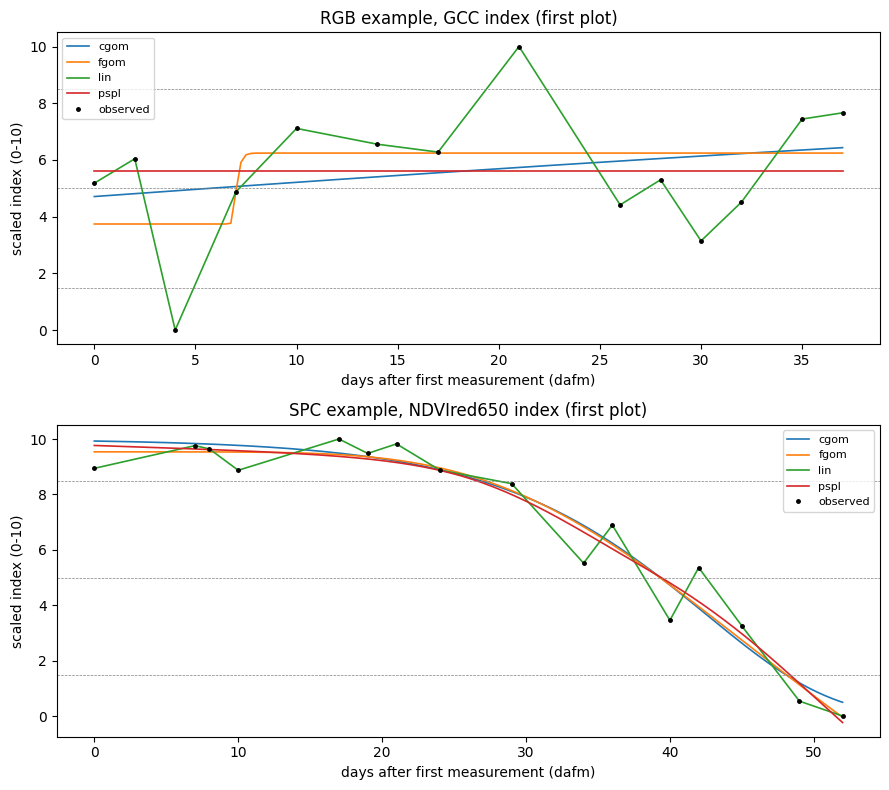

In [ ]:
import glob
import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(2, 1, figsize=(9, 8))
for ax, (stem, label) in zip(axes, [
        ("RGB_example_GCC_RGB", "RGB example, GCC index (first plot)"),
        ("SPC_example_NDVIred650_multispec_empirical_line_LM", "SPC example, NDVIred650 index (first plot)")]):
    (curve_file,) = glob.glob(f"/content/dsm/out/{stem}_curves_*.csv")
    d = pd.read_csv(curve_file)
    obs = d[d["is_observed"]]
    for m, g in d[~d["is_observed"]].groupby("method"):
        ax.plot(g["timevar"], g["prediction"], label=m, lw=1.2)
    ax.plot(obs["timevar"], obs["prediction"], "k.", ms=5, label="observed")
    for y, c in [(8.5, "grey"), (5.0, "grey"), (1.5, "grey")]:
        ax.axhline(y, color=c, lw=0.5, ls="--")
    ax.set_xlabel("days after first measurement (dafm)")
    ax.set_ylabel("scaled index (0-10)")
    ax.set_title(label)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("/content/dsm/out/fits.png", dpi=110)
plt.show()

Display the saved figure inline.

日本語: 保存した図を表示します。

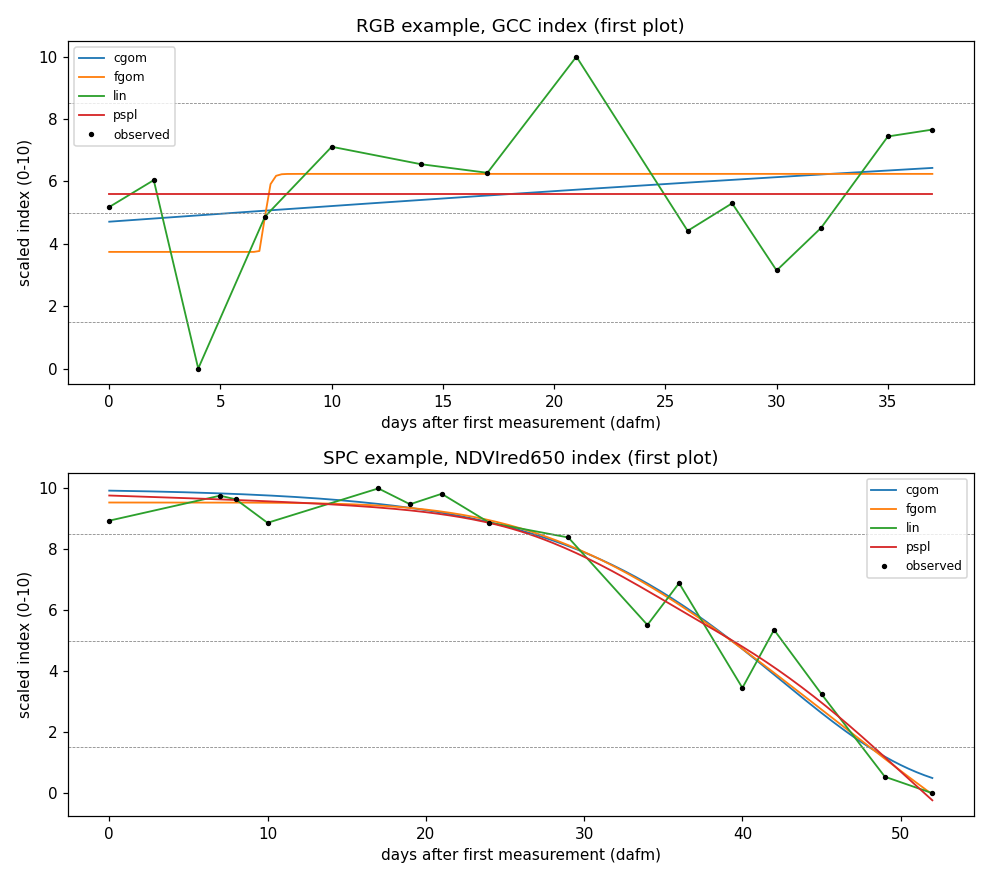

In [ ]:
from IPython.display import Image
Image("/content/dsm/out/fits.png")

## Interpretation, differences from the paper, and validation record

- **What was executed:** the authors' dynamic-modeling pipeline (scaling → 4 fitting methods → key-time-point extraction) on 2 example files × 4 plots, inside this Colab VM, from pinned commit `4798c12`.
- **Relation to the paper:** this demonstrates the "Dynamic modelling of senescence time series" and "Key senescence time point extraction" steps. The paper's conclusions (temporal resolution more important than spectral resolution; RGB vs SPC comparison; selection against visual scoring) require all four experiments and are **not** tested by this single example.
- **Known adaptations** (documented above): subset of files/plots, sequential execution, `filter_dates` skipped for example files, own figure. No scientific parameter was changed (same scaling, methods, `pred_freq=0.25`, scam `bs="mpd"` with `k = 0.8·n`, Gompertz start ranges).
- **License note:** the repository has no LICENSE file; reuse terms are unverified — cited for scholarship, per the paper's data availability statement.
- **Expected variation:** nls.multstart and scam fits can differ slightly across platforms; compare relative patterns, not digits.

References:
- Paper: bioRxiv 2023.12.13.571461v1, https://doi.org/10.1101/2023.12.13.571461
- Code: https://github.com/ftschurr/dynamic_senescence_modeling @ `4798c129f50a3f1268edc52c40609b25bff5b2ed`
- 日本語: 本ノートブックは例示用の部分実行であり、論文の結論（時間分解能の優位性など）の検証ではありません。

## Export

The full parameter table and the per-plot curve data are on the Colab VM under `/content/dsm/out/` as CSV; copy them to Drive or download them from the file browser if needed.

日本語: 結果CSVは `/content/dsm/out/` に保存されます。必要ならDriveにコピーしてください。

In [ ]:
import os
for f in sorted(os.listdir("/content/dsm/out")):
    p = os.path.join("/content/dsm/out", f)
    print(f"{f:70s} {os.path.getsize(p):>9,d} B")

RGB_example_GCC_RGB_curves_RGB0001.csv                                    30,103 B
RGB_example_GCC_RGB_pars.csv                                               1,951 B
SPC_example_NDVIred650_multispec_empirical_line_LM_curves_SPC0001.csv     46,469 B
SPC_example_NDVIred650_multispec_empirical_line_LM_pars.csv                2,317 B
fits.png                                                                 118,772 B
